In [298]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


In [396]:
df=pd.read_csv("/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv")
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [397]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [369]:
df.shape

(1338, 7)

In [363]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [364]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

checking for co- relations 

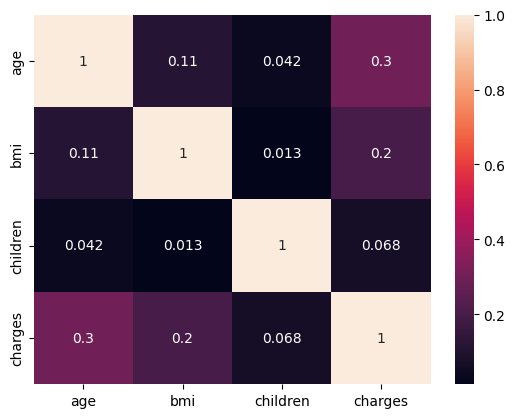

In [403]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True)

plt.show()

hence observed there is no multi-relation btw input features

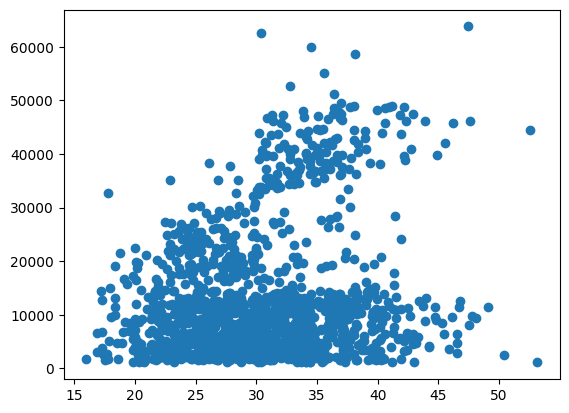

In [365]:
plt.scatter(df['bmi'],df['charges'])
plt.show()

<Axes: ylabel='charges'>

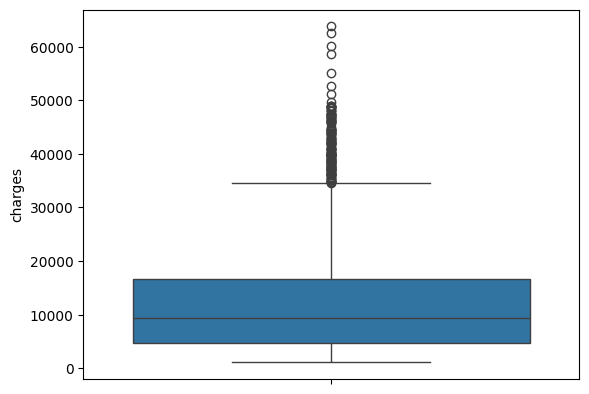

In [304]:

sns.boxplot(df['charges'])

**so outliers exists** 

In [305]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print("upper", upper)
print("lower",lower)

upper 34489.350562499996
lower -13109.1508975


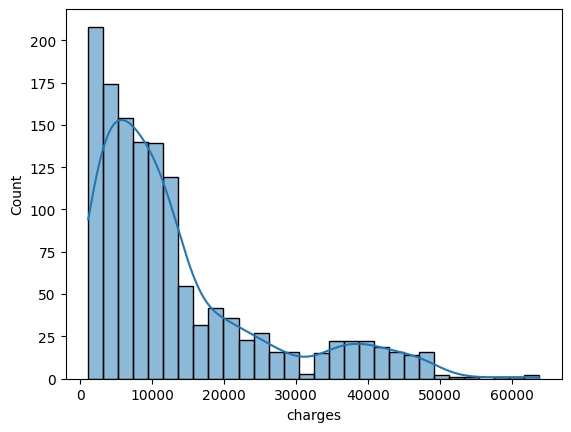

In [367]:
sns.histplot(
    df['charges'],
    kde=True
)

plt.show()

right skewed

In [398]:
df_clean = df[
    (df['charges'] >= lower)
    &
    (df['charges'] <= upper)
].copy()
df_clean['charges_log'] = np.log(df_clean['charges'])
df_clean.shape

(1199, 8)

In [399]:
df_clean.head(5)

,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


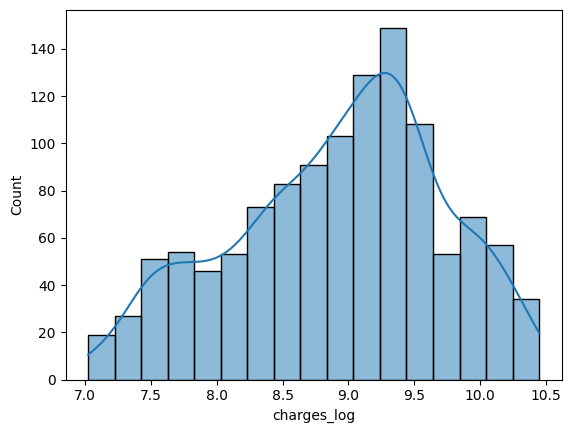

In [377]:
sns.histplot(
    df_clean['charges_log'],
    kde=True
)

plt.show()

<Axes: ylabel='charges_log'>

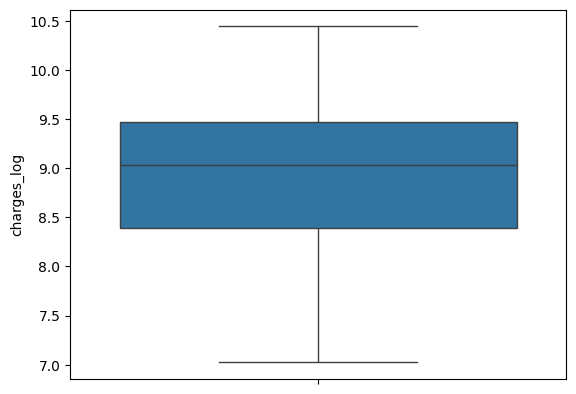

In [448]:
sns.boxplot(df_clean['charges_log'])

outliers   are resolved

In [400]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_clean["sex"] = le_sex.fit_transform(df_clean["sex"])
df_clean["smoker"] = le_smoker.fit_transform(df_clean["smoker"])
df_clean["region"] = le_region.fit_transform(df_clean["region"]) 

df_clean.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,0,27.900,0,1,3,16884.92400,9.734176
1,18,1,33.770,1,0,2,1725.55230,7.453302
2,28,1,33.000,3,0,2,4449.46200,8.400538
3,33,1,22.705,0,0,1,21984.47061,9.998092
4,32,1,28.880,0,0,1,3866.85520,8.260197


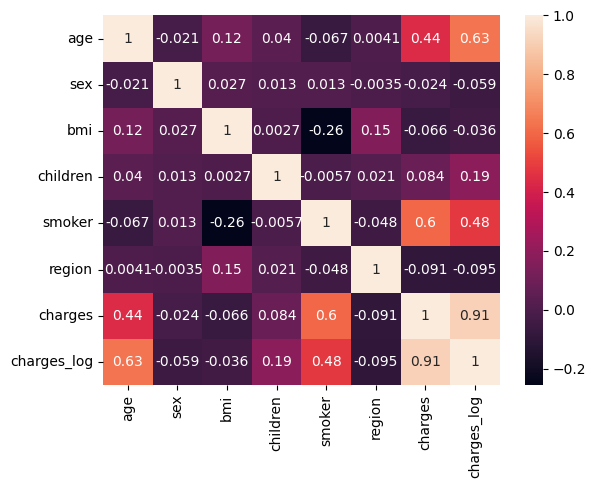

In [401]:
sns.heatmap(df_clean.corr(numeric_only=True),
            annot=True)

plt.show()

we can see there is a relationship between smoker and charge


In [405]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [406]:
X = df_clean.drop(
    ['charges', 'charges_log'],
    axis=1
)

In [407]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1


In [408]:
#log transformed)
y = df_clean['charges_log']


In [409]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [442]:
print(X_test,y_test)

      age  sex     bmi  children  smoker  region
1315   18    1  28.310         1       0       0
965    35    1  27.100         1       0       3
117    29    0  27.940         1       1       2
492    18    0  25.080         0       0       0
69     28    1  23.980         3       1       2
...   ...  ...     ...       ...     ...     ...
432    42    1  26.900         0       0       3
967    44    1  25.365         1       0       1
604    19    0  28.310         0       1       1
1331   23    0  33.400         0       0       3
974    26    1  35.420         0       0       2

[240 rows x 6 columns] 1315    9.330106
965     8.465130
117     9.857851
492     7.694608
69      9.779235
          ...   
432     8.694456
967     8.925059
604     9.768182
1331    9.286925
974     7.750452
Name: charges_log, Length: 240, dtype: float64


In [410]:
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

In [420]:
# Inverse transform to dollar scale for interpretable metrics
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred)

In [421]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [430]:
print("MAE" , mean_absolute_error(y_test_orig, y_pred_orig))
print("MSE", mean_squared_error(y_test_orig, y_pred_orig))
print("R2 score",r2_score(y_test, y_pred))

MAE 3784.7117873243847
MSE 64109627.4257287
R2 score 0.6591787131957471


performed lr on dataset after dealing with outliers now without ouliers and log transformer

For this specific dataset, outliers are not noise — they are signal. High charges from smokers/high BMI patients are genuine patterns the model should learn, not anomalies to discard. Removing them hurts generalization.

In [423]:


#case1 Young non-smoker
new_data1 = pd.DataFrame({
    'age': [40],
    'sex': [1],        # male/female encoding
    'bmi': [30],
    'children': [2],
    'smoker': [0],     # no=0, yes=1
    'region': [1]
})

y_pred_for_case1 = lr.predict(new_data1)
print(y_pred_for_case1)

[8.87598616]


In [424]:
predicted_charge1 = np.exp(y_pred_for_case1)

print("Predicted charges1:", predicted_charge1[0])

Predicted charges1: 7158.001912333399


In [425]:
#Case 2: Older smoker with high BMI
new_data2 = pd.DataFrame({
    'age':[55],
    'sex':[1],
    'bmi':[35],
    'children':[2],
    'smoker':[1],
    'region':[1]
})

In [426]:
y_pred_for_case2 = lr.predict(new_data2)
print(y_pred_for_case2)

[10.82511196]


In [427]:
predicted_charge2 = np.exp(y_pred_for_case2)

print("Predicted charges2:", predicted_charge2[0])

Predicted charges2: 50267.396429508764


In [431]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [432]:
ridge = Ridge()
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, ridge_params, scoring='r2', cv=5)
ridge_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]}, scoring='r2')

In [435]:
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

y_pred_ridge_orig = np.exp(y_pred_ridge)


print("Best alpha   :", ridge_cv.best_params_)
print("MAE ", mean_absolute_error(y_test_orig, y_pred_ridge_orig))
print("MSE", mean_squared_error(y_test_orig, y_pred_ridge_orig))
print("R2 score", r2_score(y_test, y_pred_ridge))

Best alpha   : {'alpha': 0.1}
MAE  3781.0001803290634
MSE 63917359.980127685
R2 score 0.659275845581605


In [440]:
lasso = Lasso()
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_cv = GridSearchCV(lasso, lasso_params, scoring='r2', cv=5)
lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

y_pred_lasso_orig = np.exp(y_pred_lasso)


print("Best alpha   :",lasso_cv.best_params_)
print("MAE ",mean_absolute_error(y_test_orig,y_pred_lasso_orig))
print("MSE ", mean_squared_error(y_test_orig, y_pred_lasso_orig))
print("R2 score:",r2_score(y_test, y_pred_lasso))

Best alpha   : {'alpha': 0.001}
MAE  3751.369570752641
MSE  62603447.57716449
R2 score: 0.6600141986610195


In [445]:
#Case 3: from dataset
new_data3 = pd.DataFrame({
    'age':[38],
    'sex':[0],
    'bmi':[37],
    'children':[1],
    'smoker':[0],
    'region':[3]
})
y_pred_for_case3 = lr.predict(new_data3)
print(y_pred_for_case3)
predicted_charge3 = np.exp(y_pred_for_case3)

print("Predicted charges3:", predicted_charge3[0])


[8.69824571]
Predicted charges3: 5992.390587244004


In [458]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -------- Raw df (with outliers, no log transform) --------
df_raw = df.copy()

le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df_raw["sex"]    = le_sex.fit_transform(df_raw["sex"])
df_raw["smoker"] = le_smoker.fit_transform(df_raw["smoker"])
df_raw["region"] = le_region.fit_transform(df_raw["region"])

X_raw = df_raw.drop(['charges'], axis=1)
y_raw = df_raw['charges']   # no log transform

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

lr_raw = LinearRegression()
lr_raw.fit(X_train_r, y_train_r)
y_pred_r = lr_raw.predict(X_test_r)

print("=== Without outlier removal & log transform ===")
print("=====SLR=====")
print("MAE  ", round(mean_absolute_error(y_test_r, y_pred_r), 2))
print("MSE  ", round(mean_squared_error(y_test_r, y_pred_r), 2))
print("R2 score :", round(r2_score(y_test_r, y_pred_r), 4))



# ------- Ridge on raw data -------
ridge_raw = Ridge()
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv_raw = GridSearchCV(ridge_raw, ridge_params, scoring='r2', cv=5)
ridge_cv_raw.fit(X_train_r, y_train_r)

best_ridge_raw = ridge_cv_raw.best_estimator_
y_pred_ridge_raw = best_ridge_raw.predict(X_test_r)

print("=== Ridge (raw) ===")
print("Best alpha   :", ridge_cv_raw.best_params_)
print("MAE  $", round(mean_absolute_error(y_test_r, y_pred_ridge_raw), 2))
print("MSE  $²", round(mean_squared_error(y_test_r, y_pred_ridge_raw), 2))
print("R2 score     :", round(r2_score(y_test_r, y_pred_ridge_raw), 4))

# ------- Lasso on raw data -------
lasso_raw = Lasso()
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_cv_raw = GridSearchCV(lasso_raw, lasso_params, scoring='r2', cv=5)
lasso_cv_raw.fit(X_train_r, y_train_r)

best_lasso_raw = lasso_cv_raw.best_estimator_
y_pred_lasso_raw = best_lasso_raw.predict(X_test_r)

print("\n=== Lasso (raw) ===")
print("Best alpha   :", lasso_cv_raw.best_params_)
print("MAE  $", round(mean_absolute_error(y_test_r, y_pred_lasso_raw), 2))
print("MSE  $²", round(mean_squared_error(y_test_r, y_pred_lasso_raw), 2))
print("R2 score     :", round(r2_score(y_test_r, y_pred_lasso_raw), 4))

# ------- Full comparison -------
print("\n=== Final Model Comparison (Raw Data) ===")
print(f"Linear Regression : R2 = {round(r2_score(y_test_r, y_pred_r), 4)}  MAE = {round(mean_absolute_error(y_test_r, y_pred_r), 2)}")
print(f"Ridge             : R2 = {round(r2_score(y_test_r, y_pred_ridge_raw), 4)}  MAE = {round(mean_absolute_error(y_test_r, y_pred_ridge_raw), 2)}")
print(f"Lasso             : R2 = {round(r2_score(y_test_r, y_pred_lasso_raw), 4)}  MAE = {round(mean_absolute_error(y_test_r, y_pred_lasso_raw), 2)}")

=== Without outlier removal & log transform ===
=====SLR=====
MAE   4186.51
MSE   33635210.43
R2 score : 0.7833
=== Ridge (raw) ===
Best alpha   : {'alpha': 1}
MAE  $ 4198.14
MSE  $² 33675792.15
R2 score     : 0.7831

=== Lasso (raw) ===
Best alpha   : {'alpha': 10}
MAE  $ 4192.78
MSE  $² 33669881.76
R2 score     : 0.7831

=== Final Model Comparison (Raw Data) ===
Linear Regression : R2 = 0.7833  MAE = 4186.51
Ridge             : R2 = 0.7831  MAE = 4198.14
Lasso             : R2 = 0.7831  MAE = 4192.78


**For this specific dataset, outliers are not noise — they are signal. High charges from smokers/high BMI patients are genuine patterns the model should learn, not anomalies to discard. Removing them hurts generalization.**